In [51]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import warnings
import mlflow
from model import build_design_matrix, fit_ols
from tracking import (
    log_model_validity, log_line_assumptions, log_variable_health,
    log_prediction_accuracy, log_anomalies, log_diagnostic_plots,
)

df = pd.read_csv("../data/processed/dt_transformed.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")
mlflow.set_tracking_uri("sqlite:///../mlruns.db")
mlflow.set_experiment("prism-mmm")
RUN_NAME = "extra_control_variables_diagnostics"

# Set to True when you want to record this run in MLflow
LOG_TO_MLFLOW = False

In [52]:
SAT_COLS = [
    'tv_S_adstock_norm_sat',
    'ooh_S_adstock_norm_sat',
    'print_S_adstock_norm_sat',
    'facebook_S_adstock_norm_sat',
    'search_S_adstock_norm_sat',
]

EXACT_WEEK_COLS = [f'is_week_{obs}' for obs in [25, 57, 73, 75, 109, 123]]

CONTROL_COLS = (
    ['competitor_sales_norm', 'is_holiday',
     'is_christmas', 'is_new_year', 'is_easter_monday', 'is_whit_monday', 'is_labor_day']
    + EXACT_WEEK_COLS
    + ['event1', 'event2',
       'February', 'March', 'May', 'June', 'July', 'August', 'September']
    # Oct–Jan dropped: collinear with competitor_sales_norm
)

X = build_design_matrix(df, SAT_COLS, CONTROL_COLS)
y = df['revenue']

results = fit_ols(X, y)

# Global Model Validity

In [53]:
# print(f"{'='*55}")
# print(f"  STEP 1 — GLOBAL MODEL VALIDITY")
# print(f"{'='*55}")
print(f"  F-statistic : {results.fvalue:.4f}")
sig = 'PASS — Significant' if results.f_pvalue < 0.05 else 'FAIL — Not significant'
print(f"  F p-value   : {results.f_pvalue:.4e}  ({sig})")
print(f"  R²          : {results.rsquared:.4f}")
print(f"  Adj R²      : {results.rsquared_adj:.4f}")
print()
if results.f_pvalue >= 0.05:
    print("  WARNING: Model is not statistically significant overall.")
else:
    gap = results.rsquared - results.rsquared_adj
    flag = 'WARNING: Possible overfitting' if gap > 0.05 else 'OK'
    print(f"  R² - Adj R² gap : {gap:.4f}  ({flag})")

  F-statistic : 476.4265
  F p-value   : 1.2536e-152  (PASS — Significant)
  R²          : 0.9862
  Adj R²      : 0.9841

  R² - Adj R² gap : 0.0021  (OK)


# Core Assumptions of Linear Regression

Saved → plots/mmm_validations/linearity_residuals_vs_fitted.png


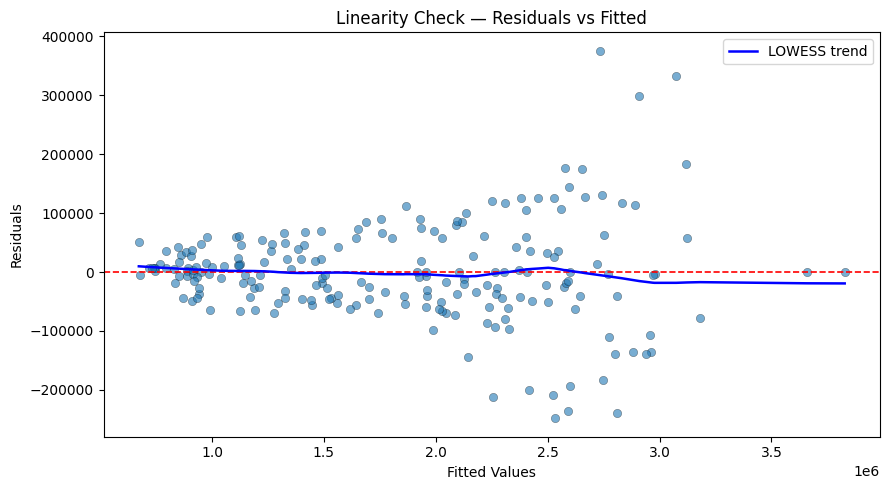

In [54]:
# L: Linearity — Residuals vs Fitted 
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

fitted    = results.fittedvalues
residuals = results.resid

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(fitted, residuals, alpha=0.6, edgecolors='k', linewidths=0.3)
ax.axhline(0, color='red', linestyle='--', linewidth=1.2)

smooth = lowess(residuals, fitted, frac=0.4)
ax.plot(smooth[:, 0], smooth[:, 1], color='blue', linewidth=1.8, label='LOWESS trend')

ax.set(xlabel='Fitted Values', ylabel='Residuals',
       title='Linearity Check — Residuals vs Fitted')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/mmm_validations/linearity_residuals_vs_fitted.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/linearity_residuals_vs_fitted.png")
plt.show()
plt.close()

  Durbin-Watson : 2.4990  (PASS — No significant autocorrelation)
  (Ideal = 2.0  |  Acceptable range: 1.5 – 2.5)
Saved → plots/mmm_validations/independence_residuals_over_time.png


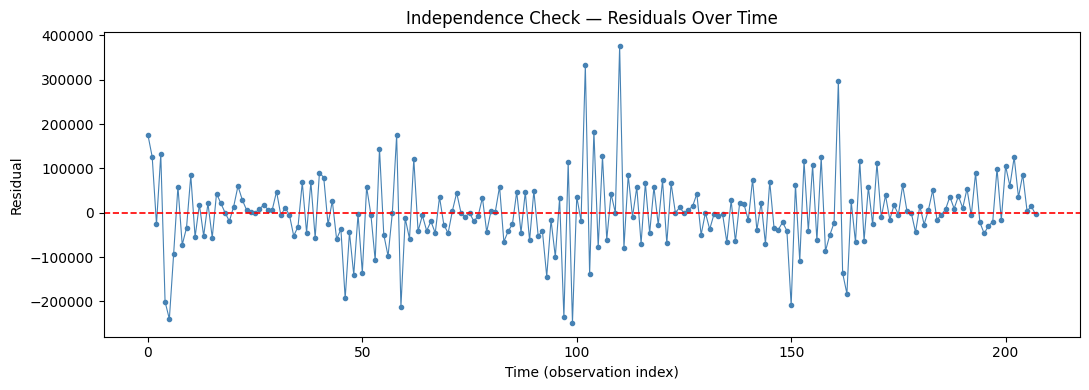

In [55]:
# I: Independence — No Autocorrelation (Durbin-Watson)
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

residuals = results.resid
dw = durbin_watson(residuals)

if dw < 1.5:
    verdict = 'FAIL — Positive autocorrelation detected'
elif dw > 2.5:
    verdict = 'FAIL — Negative autocorrelation detected'
else:
    verdict = 'PASS — No significant autocorrelation'

print(f"  Durbin-Watson : {dw:.4f}  ({verdict})")
print(f"  (Ideal = 2.0  |  Acceptable range: 1.5 – 2.5)")

# Residuals over time to visually inspect rolling patterns
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(residuals.values, marker='o', markersize=3, linewidth=0.8, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax.set(xlabel='Time (observation index)', ylabel='Residual',
       title='Independence Check — Residuals Over Time')
plt.tight_layout()
plt.savefig('../plots/mmm_validations/independence_residuals_over_time.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/independence_residuals_over_time.png")
plt.show()
plt.close()

  Jarque-Bera  : stat=118.4587, p=0.0000  (FAIL — Non-normal residuals)
  Skewness=0.4741  |  Excess Kurtosis=6.5734
  (Rely on the Q-Q plot for tail behaviour — formal tests are oversensitive at larger observations
Saved → plots/mmm_validations/normality_qq_histogram.png


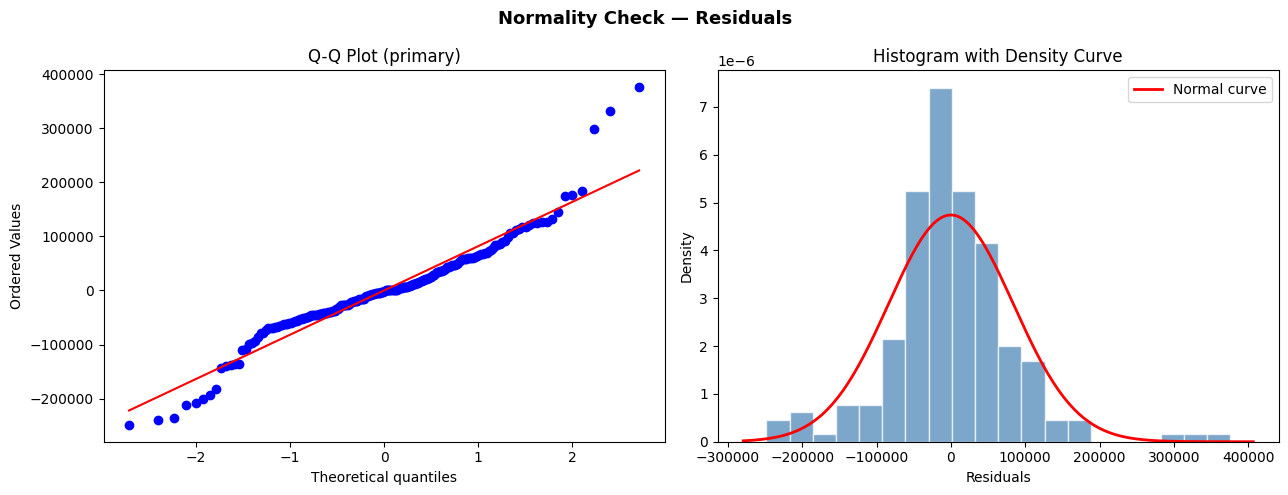

In [56]:
# N: Normality of Residuals — Q-Q Plot + Histogram with Density Curve
# Primary check: visual (Q-Q plot). Jarque-Bera (Shapiro-Wilk) is supplementary only.
# at 100+ observations formal tests become oversensitive to minor deviations.

import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from statsmodels.stats.stattools import jarque_bera

residuals = results.resid

jb_stat, jb_pval, skew, kurtosis = jarque_bera(residuals)
verdict = 'PASS — Residuals are normal' if jb_pval > 0.05 else 'FAIL — Non-normal residuals'
print(f"  Jarque-Bera  : stat={jb_stat:.4f}, p={jb_pval:.4f}  ({verdict})")
print(f"  Skewness={skew:.4f}  |  Excess Kurtosis={kurtosis:.4f}")
print(f"  (Rely on the Q-Q plot for tail behaviour — formal tests are oversensitive at larger observations")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Normality Check — Residuals', fontsize=13, fontweight='bold')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot (primary)')

# Histogram + Density Curve
axes[1].hist(residuals, bins=20, density=True, color='steelblue', edgecolor='white', alpha=0.7)
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 200)
axes[1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
             color='red', linewidth=2, label='Normal curve')
axes[1].set(xlabel='Residuals', ylabel='Density', title='Histogram with Density Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/mmm_validations/normality_qq_histogram.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/normality_qq_histogram.png")
plt.show()
plt.close()

  Breusch-Pagan : stat=97.9288, p=0.0000  (FAIL — Heteroscedastic (unequal variance))
  Refer to: plots/mmm_validations/linearity_residuals_vs_fitted.png — look for a funnel/fan shape in the spread of points.


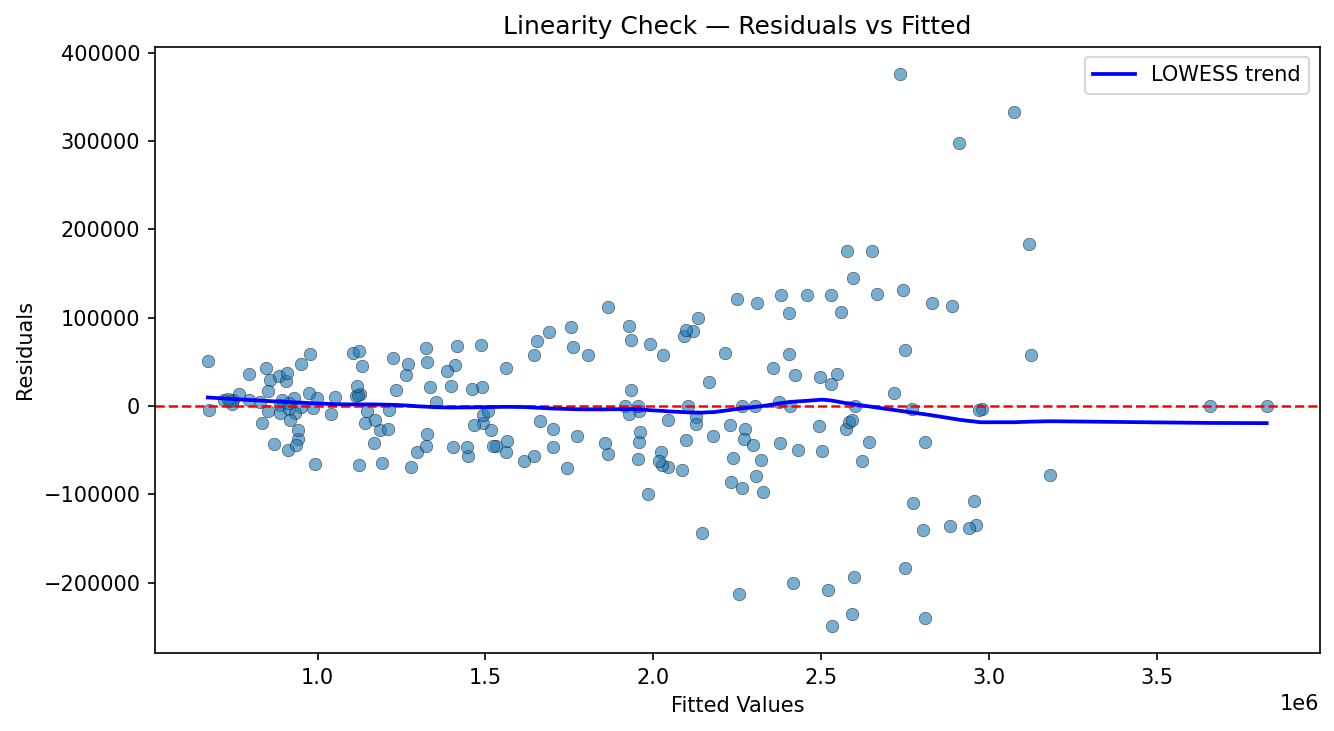

In [57]:
# ── E: Equal Variance (Homoscedasticity) — Breusch-Pagan Test
# Visual check is already covered by the Residuals vs Fitted plot above (L).
# A funnel/fan shape in that plot = heteroscedasticity.
# Breusch-Pagan is the supplementary statistical confirmation.
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = results.resid

bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, results.model.exog)
verdict = 'PASS — Homoscedastic' if bp_pval > 0.05 else 'FAIL — Heteroscedastic (unequal variance)'
print(f"  Breusch-Pagan : stat={bp_stat:.4f}, p={bp_pval:.4f}  ({verdict})")
print(f"  Refer to: plots/mmm_validations/linearity_residuals_vs_fitted.png — look for a funnel/fan shape in the spread of points.")

from IPython.display import Image
Image('../plots/mmm_validations/linearity_residuals_vs_fitted.png')

# Variable Health & Redundancy

In [58]:
# Step 3: Variable Health & Redundancy — p-values + VIF
# IMPORTANT: Always check VIF before dropping an "insignificant" channel.
# High multicollinearity inflates standard errors → lowers t-stat → raises p-value,
# making a genuinely useful channel appear insignificant.

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Coefficients & significance
coef_df = pd.DataFrame({
    'Coefficient': results.params,
    't-statistic': results.tvalues,
    'p-value'    : results.pvalues,
    'Significant': results.pvalues.map(lambda p: 'Yes' if p < 0.05 else 'No'),
}).round(4)

print("── Coefficients & Significance (α = 0.05) ──")
print(coef_df.to_string())


── Coefficients & Significance (α = 0.05) ──
                              Coefficient  t-statistic  p-value Significant
const                        1.653893e+06      47.7817   0.0000         Yes
tv_S_adstock_norm_sat        3.039708e+05       7.7377   0.0000         Yes
ooh_S_adstock_norm_sat       8.613642e+04       2.5192   0.0126         Yes
print_S_adstock_norm_sat     1.159810e+05       5.5102   0.0000         Yes
facebook_S_adstock_norm_sat  3.236345e+04       1.4323   0.1538          No
search_S_adstock_norm_sat    2.311204e+03       0.0581   0.9537          No
competitor_sales_norm        6.345055e+05      51.7544   0.0000         Yes
is_holiday                  -3.955612e+04      -1.4143   0.1590          No
is_christmas                 1.407410e+05       2.3568   0.0195         Yes
is_new_year                  4.607318e+05       7.7324   0.0000         Yes
is_easter_monday             6.511766e+05       6.6241   0.0000         Yes
is_whit_monday               5.108680e+04  

In [59]:
# VIF (constant excluded — its VIF is mathematically meaningless)
X_with_const  = results.model.exog
feature_names = results.model.exog_names

vif_df = pd.DataFrame({
    'Feature': feature_names,
    'VIF'    : [variance_inflation_factor(X_with_const, i) for i in range(X_with_const.shape[1])]
}).round(2)
vif_df = vif_df[vif_df['Feature'] != 'const']
vif_df['Flag'] = vif_df['VIF'].map(lambda v: 'HIGH ⚠' if v > 10 else ('MODERATE ⚡' if v > 5 else 'OK'))

print("── Variance Inflation Factors (VIF) ──")
print(f"  Threshold: VIF > 10 = High multicollinearity, VIF > 5 = Moderate")
print(vif_df.to_string(index=False))

── Variance Inflation Factors (VIF) ──
  Threshold: VIF > 10 = High multicollinearity, VIF > 5 = Moderate
                    Feature  VIF Flag
      tv_S_adstock_norm_sat 1.79   OK
     ooh_S_adstock_norm_sat 1.19   OK
   print_S_adstock_norm_sat 1.17   OK
facebook_S_adstock_norm_sat 1.55   OK
  search_S_adstock_norm_sat 1.46   OK
      competitor_sales_norm 3.84   OK
                 is_holiday 2.67   OK
               is_christmas 1.72   OK
                is_new_year 1.71   OK
           is_easter_monday 4.66   OK
             is_whit_monday 2.65   OK
               is_labor_day 1.95   OK
                 is_week_25 1.65   OK
                 is_week_57 1.36   OK
                 is_week_73 2.21   OK
                 is_week_75 1.53   OK
                is_week_109 1.42   OK
                is_week_123 2.19   OK
                     event1 1.67   OK
                     event2 2.16   OK
                   February 1.46   OK
                      March 1.67   OK
                    

# Prediction Accuracy

  Mean Revenue :   1,822,142.77
  RSE          :      90,227.62  (5.0% of mean)  →  Excellent  (< 10%)
  RMSE         :      83,935.19  (4.6% of mean)  →  Excellent  (< 10%)
  MAPE         :          2.99%                →  Excellent  (< 10%)
Saved → plots/mmm_validations/prediction_actual_vs_fitted.png


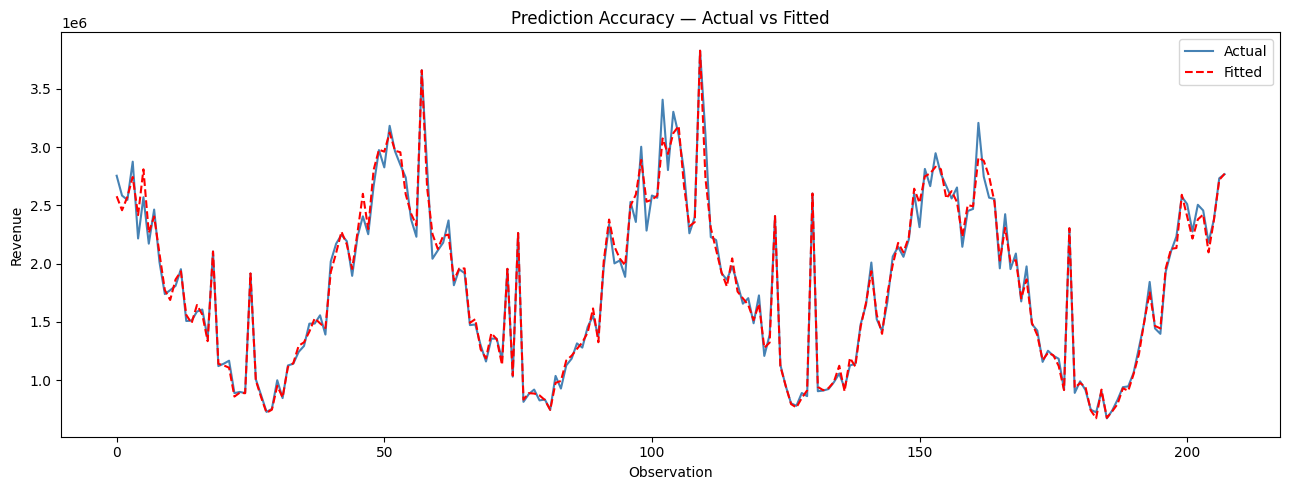

In [60]:
# Step 4: Prediction Accuracy — RSE, RMSE, MAPE 
import numpy as np
import matplotlib.pyplot as plt

y_true = results.model.endog
y_pred = results.fittedvalues
n      = len(y_true)
p      = int(results.df_model)

residuals = y_true - y_pred
rse    = np.sqrt(np.sum(residuals**2) / (n - p - 1))
rmse   = np.sqrt(np.mean(residuals**2))
mape   = np.mean(np.abs(residuals / y_true)) * 100
mean_y = np.mean(y_true)

def rse_label(pct):
    if pct < 10:   return 'Excellent  (< 10%)'
    elif pct < 20: return 'Good       (10–20%)'
    elif pct < 30: return 'Acceptable (20–30%)'
    else:          return 'Poor       (> 30%)'

def mape_label(pct):
    if pct < 10:   return 'Excellent  (< 10%)'
    elif pct < 20: return 'Good       (10–20%)'
    elif pct < 30: return 'Acceptable (20–30%)'
    else:          return 'Poor       (> 30%)'

rse_pct  = rse  / mean_y * 100
rmse_pct = rmse / mean_y * 100

print(f"  Mean Revenue : {mean_y:>14,.2f}")
print(f"  RSE          : {rse:>14,.2f}  ({rse_pct:.1f}% of mean)  →  {rse_label(rse_pct)}")
print(f"  RMSE         : {rmse:>14,.2f}  ({rmse_pct:.1f}% of mean)  →  {rse_label(rmse_pct)}")
print(f"  MAPE         : {mape:>13.2f}%                →  {mape_label(mape)}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_true, label='Actual', linewidth=1.5, color='steelblue')
ax.plot(y_pred, label='Fitted', linewidth=1.5, linestyle='--', color='red')
ax.set(xlabel='Observation', ylabel='Revenue', title='Prediction Accuracy — Actual vs Fitted')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/mmm_validations/prediction_actual_vs_fitted.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/prediction_actual_vs_fitted.png")
plt.show()
plt.close()

# Anomalies & Influential Points

  Threshold : |Studentized Residual| > 3
  Count     : 4 / 208 (1.9%)
  Outliers  : [np.int64(5), np.int64(102), np.int64(110), np.int64(161)]
Saved → plots/mmm_validations/outliers_studentized_residuals.png


/Users/temit/Documents/Project/Ekimetrics/prism-mmm/venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


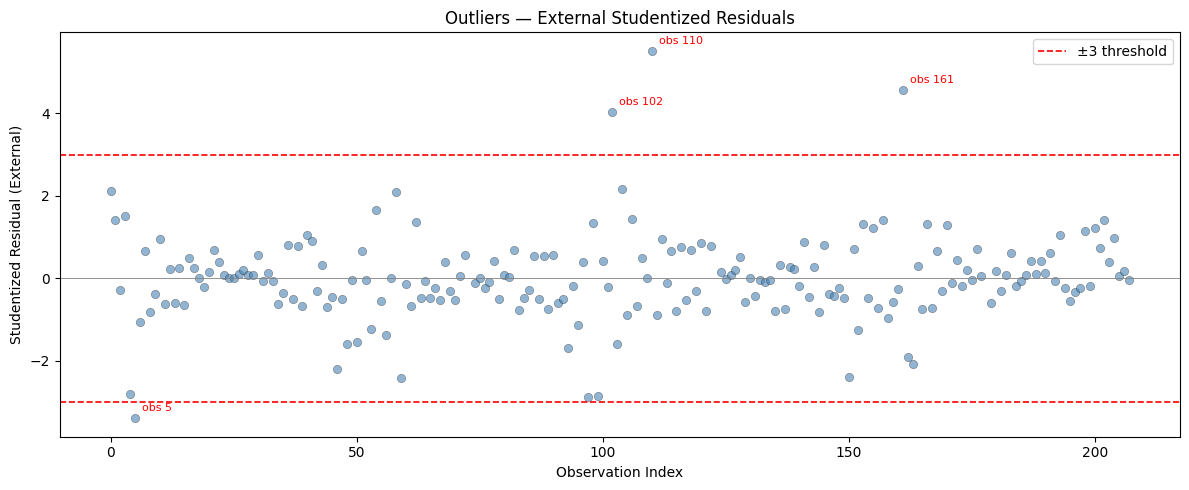

In [61]:
# Outliers — External Studentized Residuals
# Using external (jackknife) residuals — each is computed by refitting the model
# without that observation, avoiding the sqrt(1-hii) instability from internal residuals.
# Flag: |studentized residual| > 3

import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import OLSInfluence

influence         = OLSInfluence(results)
studentized_resid = influence.resid_studentized_external
n                 = len(studentized_resid)
outliers          = np.where(np.abs(studentized_resid) > 3)[0]

print(f"  Threshold : |Studentized Residual| > 3")
print(f"  Count     : {len(outliers)} / {n} ({len(outliers)/n*100:.1f}%)")
print(f"  Outliers  : {list(outliers) if len(outliers) else 'None'}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(range(n), studentized_resid, alpha=0.6, edgecolors='k', linewidths=0.3, color='steelblue')
ax.axhline( 3, color='red', linestyle='--', linewidth=1.2, label='±3 threshold')
ax.axhline(-3, color='red', linestyle='--', linewidth=1.2)
ax.axhline( 0, color='grey', linestyle='-', linewidth=0.6)
for i in outliers:
    ax.annotate(f'obs {i}', (i, studentized_resid[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=8, color='red')
ax.set(xlabel='Observation Index', ylabel='Studentized Residual (External)',
       title='Outliers — External Studentized Residuals')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/mmm_validations/outliers_studentized_residuals.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/outliers_studentized_residuals.png")
plt.show()
plt.close()
print()

  Threshold   : (p+1)/n = (27+1)/208 = 0.1346
  Count       : 32 / 208 (15.4%)
  High Leverage Points : [np.int64(4), np.int64(5), np.int64(17), np.int64(18), np.int64(22), np.int64(23), np.int64(25), np.int64(45), np.int64(56), np.int64(57), np.int64(72), np.int64(73), np.int64(75), np.int64(76), np.int64(78), np.int64(80), np.int64(92), np.int64(97), np.int64(109), np.int64(110), np.int64(122), np.int64(123), np.int64(127), np.int64(128), np.int64(130), np.int64(161), np.int64(162), np.int64(177), np.int64(178), np.int64(179), np.int64(185), np.int64(201)]
Saved → plots/mmm_validations/high_leverage.png


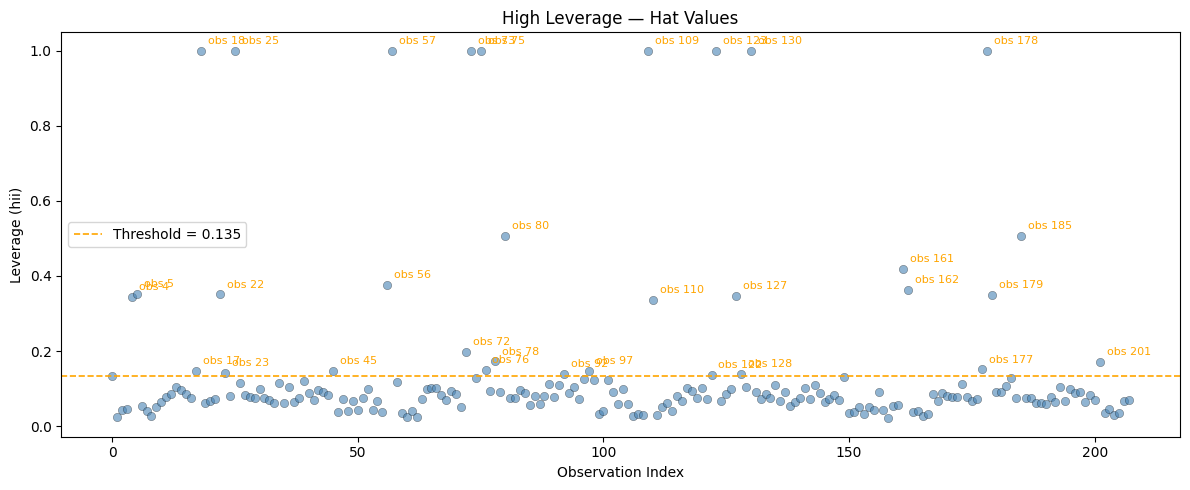

In [62]:
# ── High Leverage — Hat Values ─────────────────────────────────────────────────
# Extreme input (ad spend), normal sales. High leverage points act like a magnet
# and can pull the regression line toward them.
# Flag: hii > (p+1)/n

import matplotlib.pyplot as plt
import numpy as np

leverage           = influence.hat_matrix_diag
p                  = int(results.df_model)
n                  = len(leverage)
threshold          = (p + 1) / n
high_lev           = np.where(leverage > threshold)[0]

print(f"  Threshold   : (p+1)/n = ({p}+1)/{n} = {threshold:.4f}")
print(f"  Count       : {len(high_lev)} / {n} ({len(high_lev)/n*100:.1f}%)")
print(f"  High Leverage Points : {list(high_lev) if len(high_lev) else 'None'}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(range(n), leverage, alpha=0.6, edgecolors='k', linewidths=0.3, color='steelblue')
ax.axhline(threshold, color='orange', linestyle='--', linewidth=1.2, label=f'Threshold = {threshold:.3f}')
for i in high_lev:
    ax.annotate(f'obs {i}', (i, leverage[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=8, color='orange')
ax.set(xlabel='Observation Index', ylabel='Leverage (hii)',
       title='High Leverage — Hat Values')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/mmm_validations/high_leverage.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/high_leverage.png")
plt.show()
plt.close()

  Threshold    : 4/n = 4/208 = 0.0192
  Influential  : 16 / 208 (7.7%)
  Indices      : [np.int64(0), np.int64(4), np.int64(5), np.int64(18), np.int64(25), np.int64(56), np.int64(57), np.int64(58), np.int64(75), np.int64(97), np.int64(102), np.int64(109), np.int64(110), np.int64(130), np.int64(161), np.int64(162)]

  Also flagged as Outliers : 4 — [np.int64(5), np.int64(102), np.int64(110), np.int64(161)]
Saved → plots/mmm_validations/cooks_distance.png


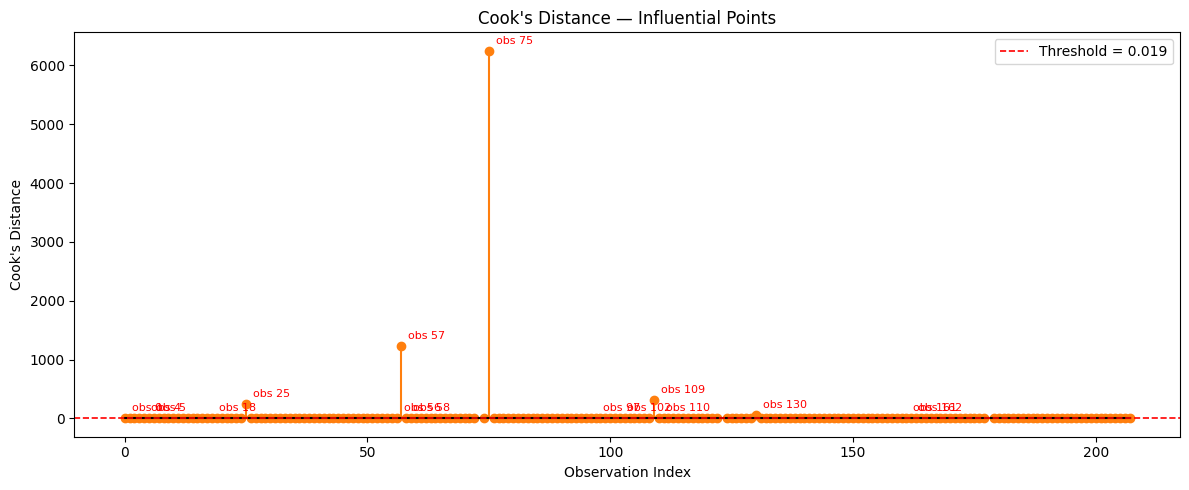

In [63]:
# Cook's Distance
# Bridges outliers + leverage. Measures how much all fitted values change
# if observation i is removed. Flags points truly distorting coefficients.
# Threshold: 4/n
import matplotlib.pyplot as plt
import numpy as np

cooks_d     = influence.cooks_distance[0]
n           = len(cooks_d)
threshold   = 4 / n
influential = np.where(cooks_d > threshold)[0]

# Cross-reference with outliers and high leverage
both = np.intersect1d(influential, outliers)

print(f"  Threshold    : 4/n = 4/{n} = {threshold:.4f}")
print(f"  Influential  : {len(influential)} / {n} ({len(influential)/n*100:.1f}%)")
print(f"  Indices      : {list(influential) if len(influential) else 'None'}")
print()
print(f"  Also flagged as Outliers : {len(both)} — {list(both) if len(both) else 'None'}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.stem(range(n), cooks_d, markerfmt='C1o', linefmt='C1-', basefmt='k-')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=f"Threshold = {threshold:.3f}")
for i in influential:
    ax.annotate(f'obs {i}', (i, cooks_d[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=8, color='red')
ax.set(xlabel='Observation Index', ylabel="Cook's Distance",
       title="Cook's Distance — Influential Points")
ax.legend()
plt.tight_layout()
plt.savefig('../plots/mmm_validations/cooks_distance.png', dpi=150, bbox_inches='tight')
print("Saved → plots/mmm_validations/cooks_distance.png")
plt.show()
plt.close()

# MLflow — Log All Diagnostic Results

In [64]:
if LOG_TO_MLFLOW:
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.stattools import jarque_bera

    residuals = results.resid
    dw        = durbin_watson(residuals)
    bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, results.model.exog)
    jb_stat, jb_pval, jb_skew, jb_kurt = jarque_bera(residuals)

    with mlflow.start_run(run_name=RUN_NAME) as run:
        log_model_validity(results)
        log_line_assumptions(dw, bp_pval, jb_pval, jb_skew, jb_kurt)
        log_variable_health(results, vif_df)
        log_prediction_accuracy(rse, rmse, mape, mean_y)
        log_anomalies(outliers, high_lev, influential)
        log_diagnostic_plots("../plots/mmm_validations")
        print(f"MLflow run logged : {run.info.run_id}")
        print(f"Launch UI         : mlflow ui --backend-store-uri sqlite:///mlruns.db")
else:
    print("Skipping MLflow logging (LOG_TO_MLFLOW = False)")

Skipping MLflow logging (LOG_TO_MLFLOW = False)


## Model Diagnostic Notes

**Why Normality (N) technically fails but is practically fine**

The test says the residuals are not normal, but the skewness is 0.49, which is very close to zero. A skewness of zero means perfectly symmetric, so 0.49 is nearly there. The real problem is the kurtosis (6.47), which means a small number of weeks have very large errors. These are the big holiday weeks where revenue shoots far above normal. We added dummy variables for these weeks and they helped a lot, but a few extreme weeks still leave large errors that the model cannot fully explain. Also, at 208 data points, the normality test becomes very picky and will flag even tiny problems. The Q-Q plot is the better check here, and it looks reasonable.

**Why Equal Variance (E) fails and what we tried**

The model makes small errors on quiet weeks and big errors on big holiday weeks. This happens because the data itself behaves that way. We tried three standard fixes:

1. **Log transformation** on revenue. It made things worse because the holiday spikes became even harder to explain.
2. **Weighted Least Squares (WLS)**. This tried to give less importance to the noisy holiday weeks. It removed outliers completely but broke the normality check badly.
3. **Exact week dummy variables** for the 6 worst holiday weeks. This was the best fix and brought skewness down from 2.4 to 0.49.

There is no clean fix left. The unequal variance comes from the data itself: some weeks are just very different from others and no regression trick fully solves that. The model coefficients are still correct. The only downside is that our confidence intervals are slightly wider than they could be. Given the model has an R-squared of 0.9866 and a prediction error of only 2.98%, this is acceptable and we move forward.